# Prompt Chaining Workflow — LangGraph

A simple workflow to understand the **Prompt Chaining** pattern in
LangGraph: the output of one LLM call becomes the input to the next
LLM call, step by step, in a chain.

**What it does:**

- Takes ONE thing as INPUT: a `topic`.
- Step 1 → LLM generates an OUTLINE for the topic.
- Step 2 → LLM expands that outline into a full BLOG post.
- Returns the final blog post as the OUTPUT.

**How it's built:**

- The whole workflow is represented as a **GRAPH** — two nodes
  connected in a straight line (node + edges + state), the LangGraph
  way of doing prompt chaining.
- It has a **STATE** — a shared dictionary that holds `topic`,
  `outline`, and `blog`. Each node reads what it needs from the
  state, calls the LLM, and writes its result back into the state.


In [3]:
from typing import TypedDict


class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [4]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model="llama-3.1-8b-instant")

In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]

    # form a prompt
    prompt = f"Create a detailed outline for a blog post on the topic: {title}"

    # ask the llm to generate the outline
    outline = model.invoke(prompt).content

    # update the outline in the state
    state["outline"] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]

    # form a prompt
    prompt = f"Write a detailed blog post on the title '{title}', using the following outline:\n{outline}"

    # ask the llm to generate the full blog content
    content = model.invoke(prompt).content

    # update the content in the state
    state["content"] = content

    return state

In [7]:
from langgraph.graph import StateGraph, START, END

# define the graph
graph = StateGraph(BlogState)

# define nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

# add edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

# compile graph
workflow = graph.compile()

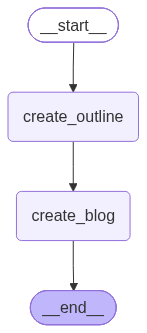

In [8]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [9]:
# execute the graph
initial_state = {"title": "The Rise of Artificial Intelligence"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'The Rise of Artificial Intelligence', 'outline': "**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its importance\n* Historical context: early developments in AI and its evolution over time\n* Thesis statement: The rise of Artificial Intelligence has transformed industries, revolutionized the way we live and work, and has the potential to shape the future of humanity.\n\n**II. The Early Days of AI**\n\n* Overview of the Dartmouth Summer Research Project on Artificial Intelligence (1956)\n* Key players: John McCarthy, Marvin Minsky, and Frank Rosenblatt\n* Early AI applications: ELIZA (1966) and MYCIN (1976)\n* Challenges and limitations of early AI: rule-based systems and lack of machine learning capabilities\n\n**III. The AI Winter and Its Revival**\n\n* The AI winter (1980s-1990s): reduced funding and interest in AI research\n* Factors contributing to the AI winter: lack of breakthroughs, limited computational power, and skepticism\n* Revival of 

In [ ]:
print(final_state["outline"])

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its importance
* Historical context: early developments in AI and its evolution over time
* Thesis statement: The rise of Artificial Intelligence has transformed industries, revolutionized the way we live and work, and has the potential to shape the future of humanity.

**II. The Early Days of AI**

* Overview of the Dartmouth Summer Research Project on Artificial Intelligence (1956)
* Key players: John McCarthy, Marvin Minsky, and Frank Rosenblatt
* Early AI applications: ELIZA (1966) and MYCIN (1976)
* Challenges and limitations of early AI: rule-based systems and lack of machine learning capabilities

**III. The AI Winter and Its Revival**

* The AI winter (1980s-1990s): reduced funding and interest in AI research
* Factors contributing to the AI winter: lack of breakthroughs, limited computational power, and skepticism
* Revival of AI research: advancements in machine learning, natural language processing, an